# 🎯 Week 4 – Customer Churn Prediction
## Advanced Machine Learning, Hyperparameter Tuning & Model Optimization
**Intern:** Ali Akaash | **Supervisor:** Qamar Naveed | **Due:** 3 July 2026

## 📦 Step 1 – Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, joblib, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.svm           import SVC
from sklearn.metrics       import (accuracy_score, precision_score,
                                   recall_score, f1_score, roc_auc_score,
                                   confusion_matrix, roc_curve, auc)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2 – Load Dataset

In [2]:
df = pd.read_csv('churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,ID-0000,Male,0,No,No,66,Yes,No,Fiber optic,No internet service,...,No internet service,No,No internet service,Yes,One year,No,Electronic check,99.91,6636.03,Yes
1,ID-0001,Female,1,No,No,24,Yes,No,Fiber optic,Yes,...,No,No internet service,No,No internet service,Two year,No,Credit card (automatic),113.97,2671.12,Yes
2,ID-0002,Male,0,No,No,60,Yes,No,Fiber optic,No internet service,...,No,No,Yes,No,Month-to-month,Yes,Mailed check,52.27,3103.86,No
3,ID-0003,Male,0,Yes,No,25,Yes,No,DSL,No,...,Yes,No,No internet service,Yes,Month-to-month,Yes,Electronic check,81.85,2067.15,No
4,ID-0004,Male,0,Yes,No,33,Yes,Yes,DSL,Yes,...,No,No,No,Yes,One year,Yes,Bank transfer (automatic),41.07,1364.26,No


In [3]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str  

In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn %:")
print(df['Churn'].value_counts(normalize=True).round(3)*100)

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 0

Churn Distribution:
Churn
No     5497
Yes    1546
Name: count, dtype: int64

Churn %:
Churn
No     78.0
Yes    22.0
Name: proportion, dtype: float64


## 🔧 Step 3 – Data Preprocessing & Feature Engineering

In [5]:
# Drop irrelevant column
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (spaces → NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (7043, 20)


In [6]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# One-Hot Encode multi-class columns
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(f"Shape after encoding: {df.shape}")
df.head(3)

Shape after encoding: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,0,0,66,1,0,99.91,6636.03,1,...,False,True,False,False,True,True,False,False,True,False
1,0,1,0,0,24,1,0,113.97,2671.12,1,...,False,False,False,True,False,False,True,True,False,False
2,1,0,0,0,60,1,1,52.27,3103.86,0,...,False,False,True,False,False,False,False,False,False,True


In [7]:
# Feature Engineering – new meaningful features
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['TenureGroup']     = pd.cut(df['tenure'], bins=[-1,12,24,48,72],
                                labels=[0,1,2,3]).astype(int)
print("✅ New features added: AvgMonthlySpend, TenureGroup")

✅ New features added: AvgMonthlySpend, TenureGroup


In [8]:
from sklearn.feature_selection import VarianceThreshold

X_all = df.drop('Churn', axis=1)
y_all = df['Churn']

selector  = VarianceThreshold(threshold=0.01)
X_sel     = selector.fit_transform(X_all)
sel_cols  = X_all.columns[selector.get_support()]
print(f"Features: {X_all.shape[1]} → {len(sel_cols)} after variance filtering")

X = pd.DataFrame(X_sel, columns=sel_cols)
y = y_all.reset_index(drop=True)

Features: 32 → 32 after variance filtering


In [9]:
# Scale numerical features
scaler   = StandardScaler()
num_cols = [c for c in ['tenure','MonthlyCharges','TotalCharges',
                         'AvgMonthlySpend','TenureGroup'] if c in X.columns]
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"✅ Scaling done | Train: {X_train.shape} | Test: {X_test.shape}")

✅ Scaling done | Train: (5634, 32) | Test: (1409, 32)


## 📊 Step 4 – Exploratory Data Analysis (EDA)

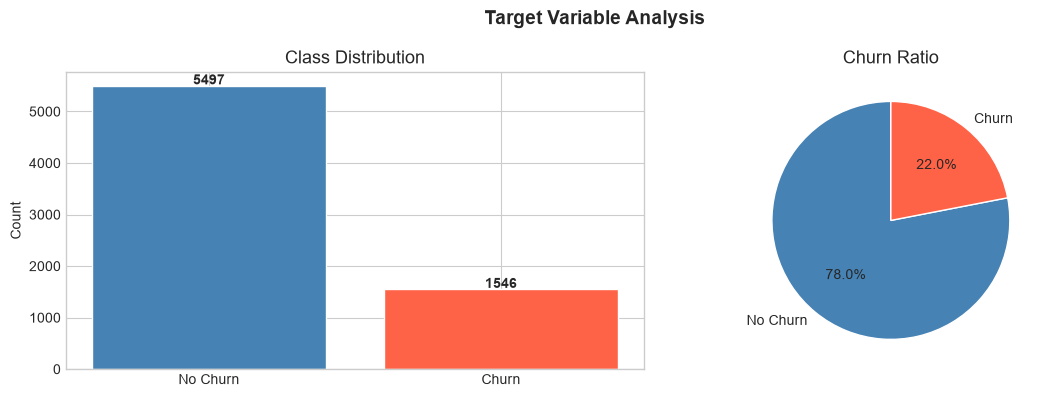

✅ Saved → reports/class_distribution.png


In [10]:
# Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = y.value_counts()

axes[0].bar(['No Churn','Churn'], counts, color=['steelblue','tomato'], edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=['No Churn','Churn'], autopct='%1.1f%%',
            colors=['steelblue','tomato'], startangle=90,
            wedgeprops={'edgecolor':'white'})
axes[1].set_title('Churn Ratio', fontsize=13)
plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/class_distribution.png")

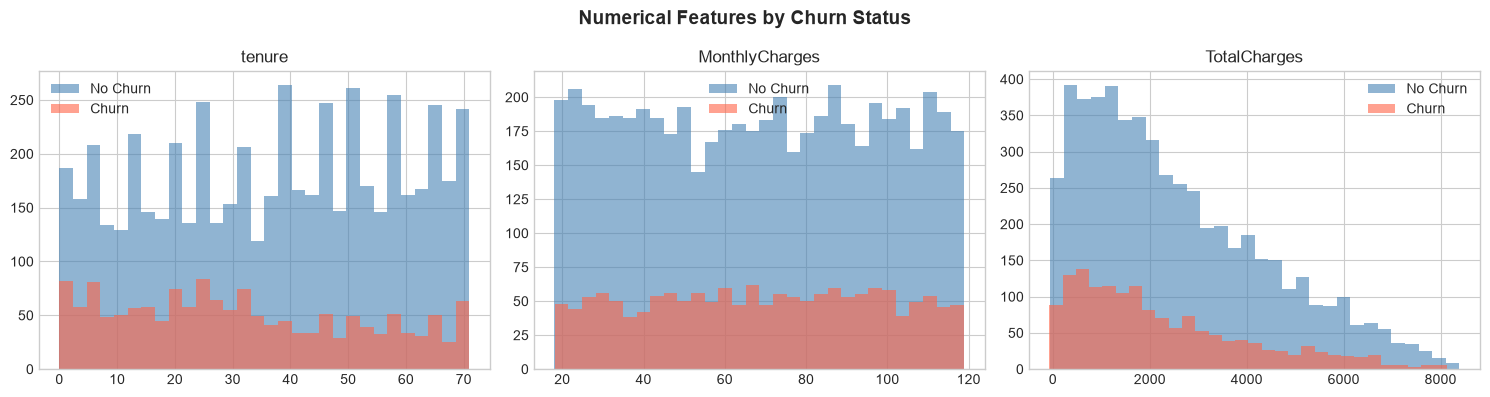

✅ Saved → reports/histograms.png


In [11]:
# Histograms by Churn Status
orig = pd.read_csv('churn.csv')
orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
orig['Churn'] = orig['Churn'].map({'Yes':1,'No':0})
num_features = ['tenure','MonthlyCharges','TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_features):
    for val, color, label in [(0,'steelblue','No Churn'),(1,'tomato','Churn')]:
        axes[i].hist(orig.loc[orig['Churn']==val, col].dropna(),
                     bins=30, alpha=0.6, color=color, label=label)
    axes[i].set_title(col, fontsize=12)
    axes[i].legend()
plt.suptitle('Numerical Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/histograms.png")

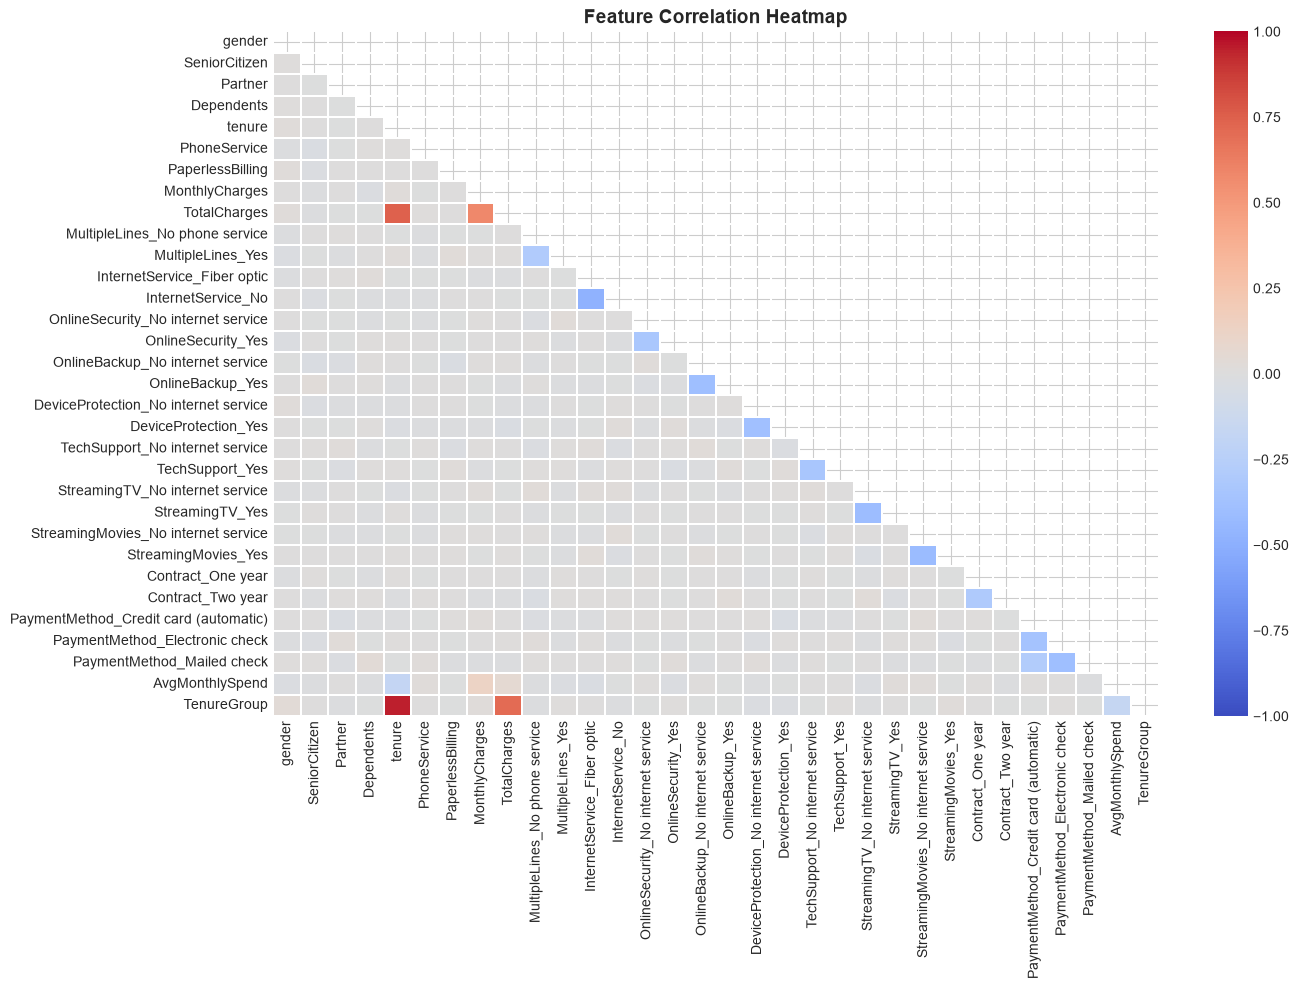

✅ Saved → reports/correlation_heatmap.png


In [12]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', annot=False,
            linewidths=0.3, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/correlation_heatmap.png")

## 🤖 Step 5 – Train 5 ML Models

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
    'SVM'                : SVC(kernel='rbf', probability=True, random_state=42)
}

results, trained = [], {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4)
    })
    print(f"✅ {name} trained")

results_df = pd.DataFrame(results)
print("\n" + "="*70)
print(results_df.to_string(index=False))
print("="*70)

✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained
✅ KNN trained
✅ SVM trained

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7736     0.2727  0.0194    0.0363   0.7104
      Decision Tree    0.6565     0.2419  0.2654    0.2531   0.5159
      Random Forest    0.7771     0.1429  0.0032    0.0063   0.6686
                KNN    0.7310     0.2426  0.1068    0.1483   0.5928
                SVM    0.7807     0.0000  0.0000    0.0000   0.6090


## 📈 Step 6 – Model Evaluation & Visualizations

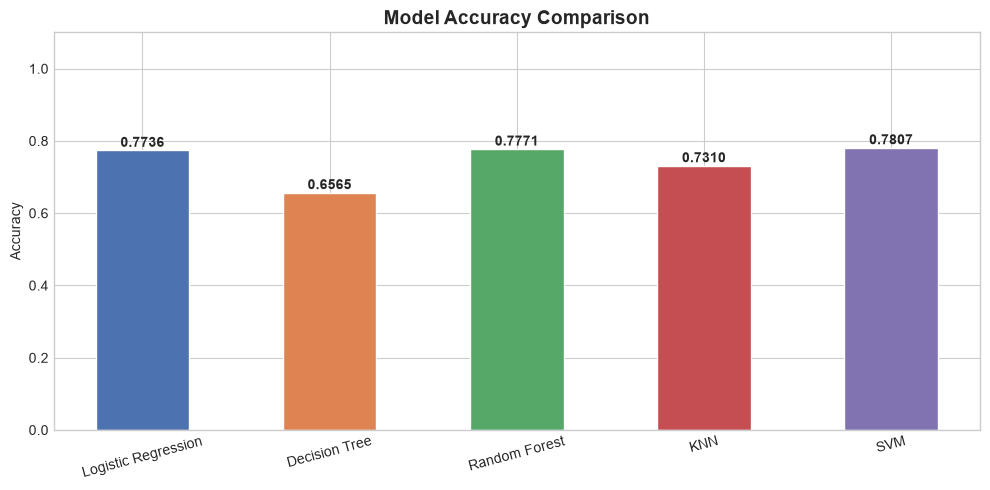

In [14]:
# Accuracy Comparison
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(results_df['Model'], results_df['Accuracy'],
              color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
              edgecolor='white', width=0.5)
ax.set_ylim(0, 1.1)
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
for bar, val in zip(bars, results_df['Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

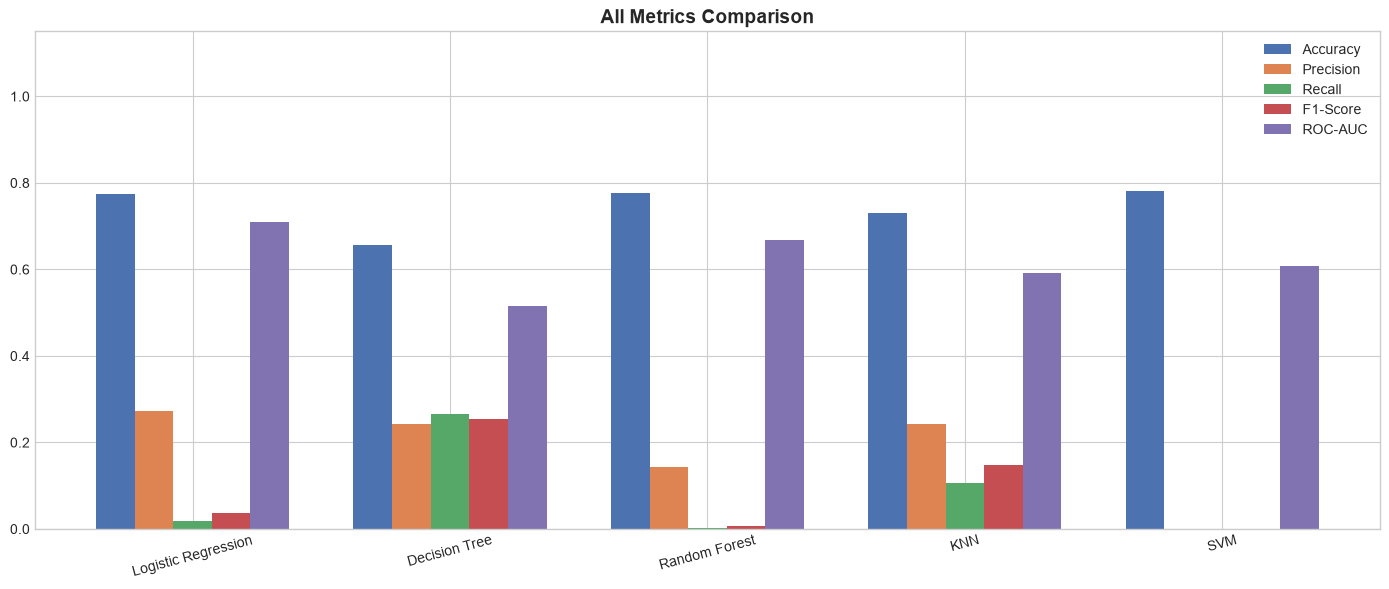

In [15]:
# All Metrics Grouped Bar
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(results_df))
width = 0.15
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[m], width, label=m, color=c)
ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df['Model'], rotation=15)
ax.set_ylim(0, 1.15)
ax.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

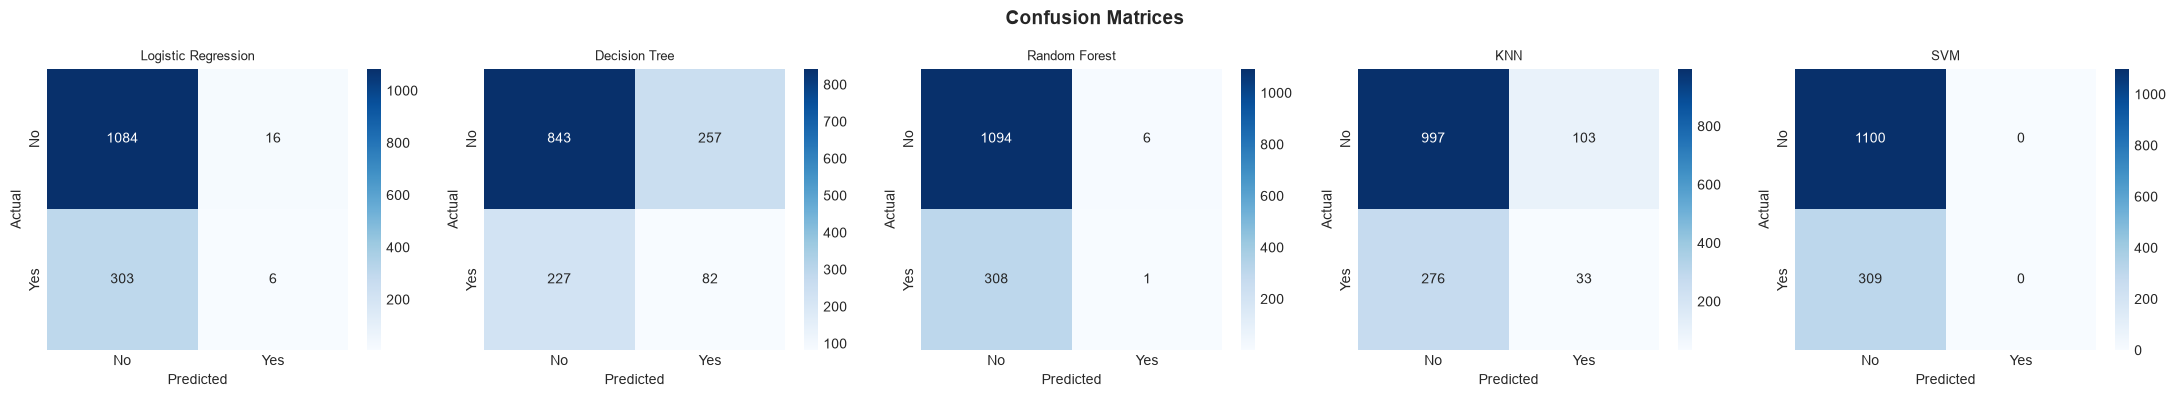

In [16]:
# Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, model) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

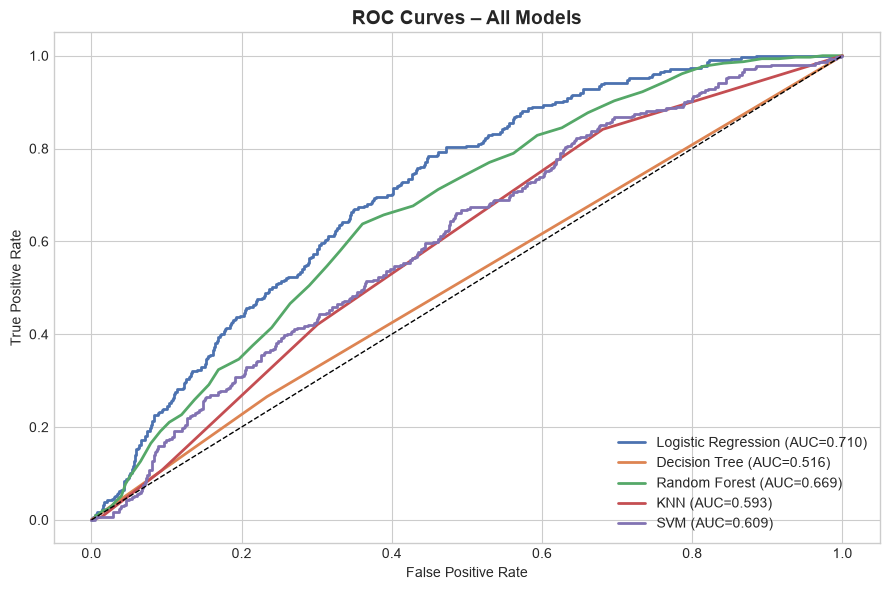

✅ All evaluation charts saved in reports/


In [17]:
# ROC Curves
fig, ax = plt.subplots(figsize=(9, 6))
for (name, model), color in zip(trained.items(),
        ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves – All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All evaluation charts saved in reports/")

## ⭐ Step 7 – Feature Importance

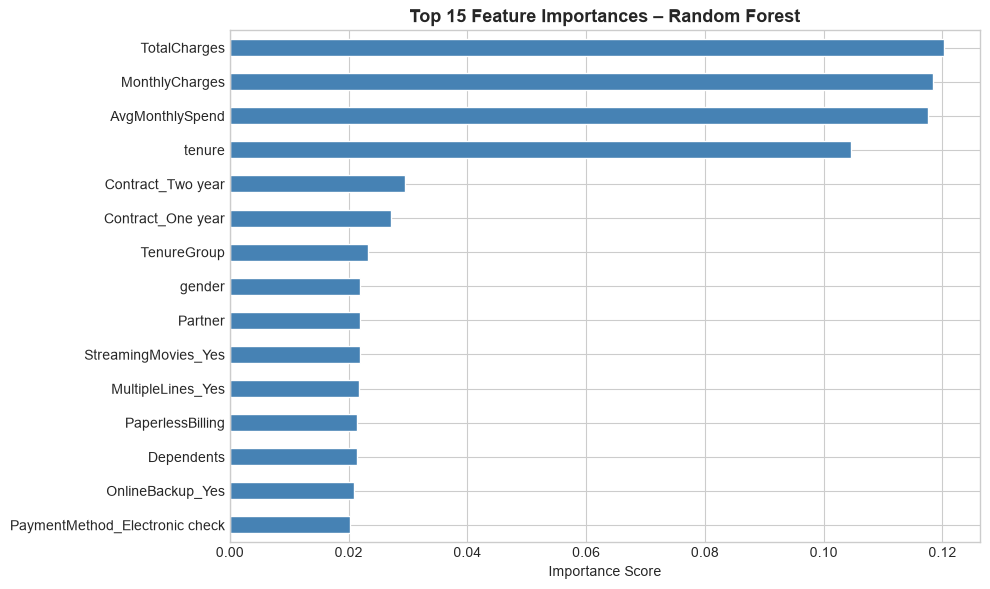

✅ Saved → reports/feature_importance.png


In [18]:
# Feature Importance using Random Forest
rf = trained['Random Forest']
importance = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importance.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top15.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Feature Importances – Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/feature_importance.png")

## 🔧 Step 8 – Hyperparameter Tuning (Random Forest)

In [19]:
baseline_f1 = f1_score(y_test, trained['Random Forest'].predict(X_test))
print(f"Baseline RF F1-Score: {baseline_f1:.4f}")
print("\nRunning GridSearchCV ... (2-3 min)")

param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}
grid_cv = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0)
grid_cv.fit(X_train, y_train)
print("GridSearchCV Best Params:", grid_cv.best_params_)
print(f"GridSearchCV Best F1    : {grid_cv.best_score_:.4f}")

Baseline RF F1-Score: 0.0063

Running GridSearchCV ... (2-3 min)
GridSearchCV Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
GridSearchCV Best F1    : 0.0398


In [20]:
print("Running RandomizedSearchCV ...")
param_dist = {
    'n_estimators'     : [50, 100, 200, 300],
    'max_depth'        : [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}
rand_cv = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                              param_dist, n_iter=20, cv=5, scoring='f1',
                              random_state=42, n_jobs=-1, verbose=0)
rand_cv.fit(X_train, y_train)
print("RandomizedSearchCV Best Params:", rand_cv.best_params_)
print(f"RandomizedSearchCV Best F1    : {rand_cv.best_score_:.4f}")

Running RandomizedSearchCV ...
RandomizedSearchCV Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
RandomizedSearchCV Best F1    : 0.0279


In [21]:
grid_f1 = f1_score(y_test, grid_cv.best_estimator_.predict(X_test))
rand_f1 = f1_score(y_test, rand_cv.best_estimator_.predict(X_test))

print(f"Baseline RF F1        : {baseline_f1:.4f}")
print(f"GridSearchCV F1       : {grid_f1:.4f}  ({grid_f1-baseline_f1:+.4f})")
print(f"RandomizedSearchCV F1 : {rand_f1:.4f}  ({rand_f1-baseline_f1:+.4f})")

best_tuned = grid_cv.best_estimator_ if grid_f1 >= rand_f1 else rand_cv.best_estimator_
best_tuned_label = "GridSearchCV" if grid_f1 >= rand_f1 else "RandomizedSearchCV"
print(f"\n🏆 Best Tuned: {best_tuned_label}")

Baseline RF F1        : 0.0063
GridSearchCV F1       : 0.0312  (+0.0248)
RandomizedSearchCV F1 : 0.0252  (+0.0189)

🏆 Best Tuned: GridSearchCV


## 🔄 Step 9 – Cross Validation (Stratified K-Fold)

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

all_models = dict(trained)
all_models['RF Tuned ⭐'] = best_tuned

print("5-Fold Stratified Cross Validation Results:\n")
for name, model in all_models.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

5-Fold Stratified Cross Validation Results:

Logistic Regression       | Mean: 0.0650 | Std: 0.0132
Decision Tree             | Mean: 0.2972 | Std: 0.0282
Random Forest             | Mean: 0.0415 | Std: 0.0047
KNN                       | Mean: 0.1830 | Std: 0.0115
SVM                       | Mean: 0.0000 | Std: 0.0000
RF Tuned ⭐                | Mean: 0.0369 | Std: 0.0212


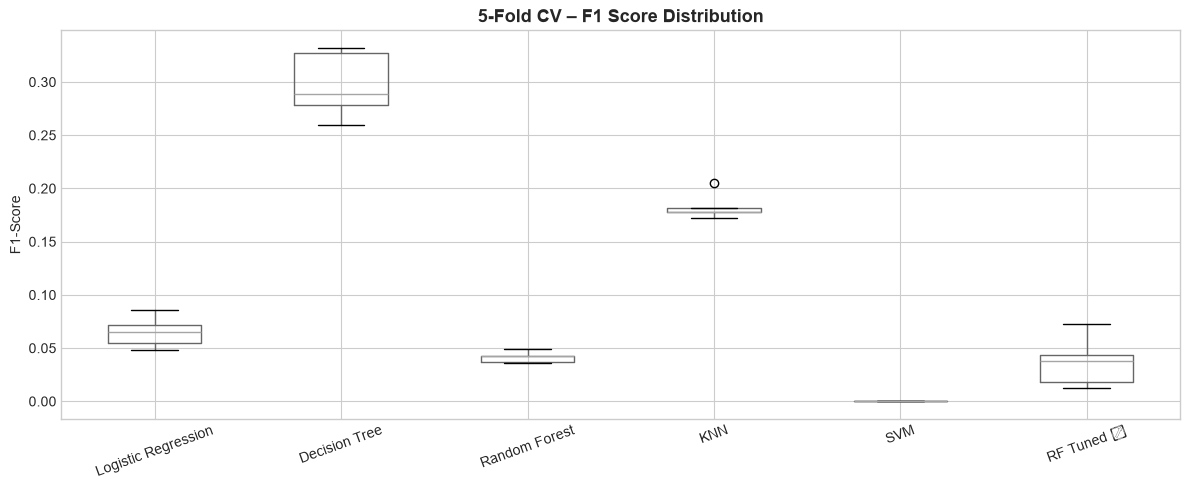

✅ Saved → reports/cross_validation.png


In [23]:
# CV Box Plot
cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(12, 5))
cv_df.boxplot(ax=ax)
ax.set_title('5-Fold CV – F1 Score Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_xticklabels(cv_df.columns, rotation=20)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → reports/cross_validation.png")

## 💾 Step 10 – Save Model & Scaler

In [24]:
os.makedirs('.', exist_ok=True)

joblib.dump(best_tuned, 'best_model.pkl')
print("✅ best_model.pkl saved")

joblib.dump(scaler, 'scaler.pkl')
print("✅ scaler.pkl saved")

with open('feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)
print("✅ feature_names.json saved")

print("\n📁 Models:")
for fname in os.listdir('.'):
    size = os.path.getsize(f'{fname}')
    print(f"   {fname:30s} {size:>10,} bytes")

✅ best_model.pkl saved
✅ scaler.pkl saved
✅ feature_names.json saved

📁 Models:
   .ipynb_checkpoints                      0 bytes
   accuracy_comparison.png            41,218 bytes
   app.py                             23,607 bytes
   best_model.pkl                 13,239,865 bytes
   churn.csv                         963,270 bytes
   churn_analysis.ipynb              642,197 bytes
   class_distribution.png             46,292 bytes
   confusion_matrices.png             78,893 bytes
   correlation_heatmap.png           256,816 bytes
   cross_validation.png               43,525 bytes
   feature_importance.png             64,886 bytes
   feature_names.json                    771 bytes
   helpers.py                          3,569 bytes
   histograms.png                     62,700 bytes
   metrics_comparison.png             46,055 bytes
   README.md                           2,404 bytes
   requirements.txt                       80 bytes
   roc_curves.png                    134,387 bytes
  

## 📋 Step 11 – Final Summary Report

In [25]:
tuned_pred = best_tuned.predict(X_test)
tuned_prob = best_tuned.predict_proba(X_test)[:, 1]

final_row = pd.DataFrame([{
    'Model'    : 'RF Tuned ⭐',
    'Accuracy' : round(accuracy_score(y_test, tuned_pred), 4),
    'Precision': round(precision_score(y_test, tuned_pred, zero_division=0), 4),
    'Recall'   : round(recall_score(y_test, tuned_pred, zero_division=0), 4),
    'F1-Score' : round(f1_score(y_test, tuned_pred, zero_division=0), 4),
    'ROC-AUC'  : round(roc_auc_score(y_test, tuned_prob), 4)
}])
final_df = pd.concat([results_df, final_row], ignore_index=True)

print("=" * 70)
print("          FINAL MODEL COMPARISON REPORT")
print("=" * 70)
print(final_df.to_string(index=False))
print("=" * 70)

final_df.to_csv('model_comparison_report.csv', index=False)
print("\n✅ Report saved → reports/model_comparison_report.csv")
print("\n🎉 Day 1 COMPLETE!")
print("   ✅ 5 Models Trained")
print("   ✅ GridSearchCV + RandomizedSearchCV Done")
print("   ✅ 5-Fold Stratified Cross Validation Done")
print("   ✅ All Charts Saved in reports/")
print("   ✅ best_model.pkl + scaler.pkl Saved")
print("   📅 Tomorrow: Build Streamlit Dashboard (app.py)")

          FINAL MODEL COMPARISON REPORT
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7736     0.2727  0.0194    0.0363   0.7104
      Decision Tree    0.6565     0.2419  0.2654    0.2531   0.5159
      Random Forest    0.7771     0.1429  0.0032    0.0063   0.6686
                KNN    0.7310     0.2426  0.1068    0.1483   0.5928
                SVM    0.7807     0.0000  0.0000    0.0000   0.6090
         RF Tuned ⭐    0.7793     0.4167  0.0162    0.0312   0.6799

✅ Report saved → reports/model_comparison_report.csv

🎉 Day 1 COMPLETE!
   ✅ 5 Models Trained
   ✅ GridSearchCV + RandomizedSearchCV Done
   ✅ 5-Fold Stratified Cross Validation Done
   ✅ All Charts Saved in reports/
   ✅ best_model.pkl + scaler.pkl Saved
   📅 Tomorrow: Build Streamlit Dashboard (app.py)
